### Plotted:
1. Distribution of laptop prices
2. Correlation Matrix
3. Price vs RAM
4. Price vs CPU speed
5. Price vs Weight
6. Price vs Storage
7. Price vs CPU type
8. Price vs Company
9. Price vs Laptop type
10. Price vs Average brand spec rating


In [14]:
# Import Libraries and load the cleaned data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("../data/cleaned_laptop_data.csv")

df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,...,CPU_speed,CPU_core,Resolution_X,Resolution_Y,Pixel_Count,SSD,HDD,GPU_brand,Company_match,avg_brand_spec_rating
0,apple,ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,intel iris plus graphics 640,macos,1.37,...,2.3,i5,2560.0,1600.0,4096000.0,128.0,0.0,intel,apple,66.750000
1,apple,ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,intel hd graphics 6000,macos,1.34,...,1.8,i5,1440.0,900.0,1296000.0,0.0,0.0,intel,apple,66.750000
2,hp,notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,intel hd graphics 620,no os,1.86,...,2.5,i5,1920.0,1080.0,2073600.0,256.0,0.0,intel,hp,69.425373
3,apple,ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,amd radeon pro 455,macos,1.83,...,2.7,i7,2880.0,1800.0,5184000.0,512.0,0.0,amd,apple,66.750000
4,apple,ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,intel iris plus graphics 650,macos,1.37,...,3.1,i5,2560.0,1600.0,4096000.0,256.0,0.0,intel,apple,66.750000


In [15]:
# Making sure of dataframe "structure"
print(df.shape)
print(df.info())
print(df.describe())

(1174, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Company                1174 non-null   object 
 1   TypeName               1174 non-null   object 
 2   Inches                 1174 non-null   object 
 3   ScreenResolution       1174 non-null   object 
 4   Cpu                    1174 non-null   object 
 5   Ram                    1174 non-null   int64  
 6   Memory                 1174 non-null   object 
 7   Gpu                    1174 non-null   object 
 8   OpSys                  1174 non-null   object 
 9   Weight                 1174 non-null   float64
 10  Price                  1174 non-null   float64
 11  CPU_speed              1174 non-null   float64
 12  CPU_core               1174 non-null   object 
 13  Resolution_X           1174 non-null   float64
 14  Resolution_Y           1174 non-null   float6

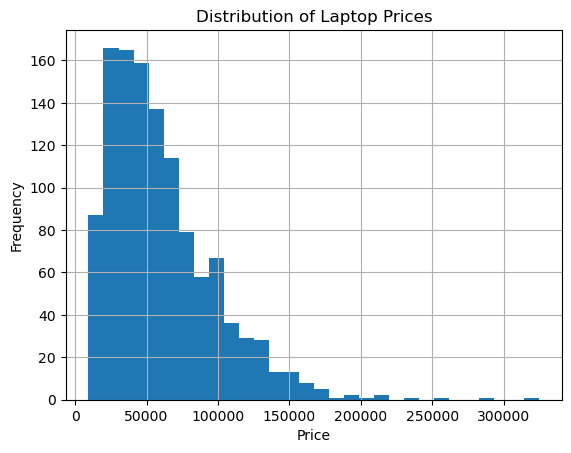

In [16]:
# Target variable plot
plt.figure()
df["Price"].hist(bins=30)
plt.title("Distribution of Laptop Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

- right skewed: long tail extending toward higher price values
- most laptops concentrated in lower to mid-price range (20 000-80 000)
- relatively few high-priced laptops, but they extend up to very large values (above 200 000), indicating outliers or premium devices
- skewness suggests that the data contains majority affordable laptops and a small number of expensive/high-end ones
- the skew also means the mean price is likely higher than the median, which justifies the use of median-based imputation during data cleaning (also explained in the data cleaning code)
- The presence of extreme values may impact regression performance; log transformation of the target variable could be considered.

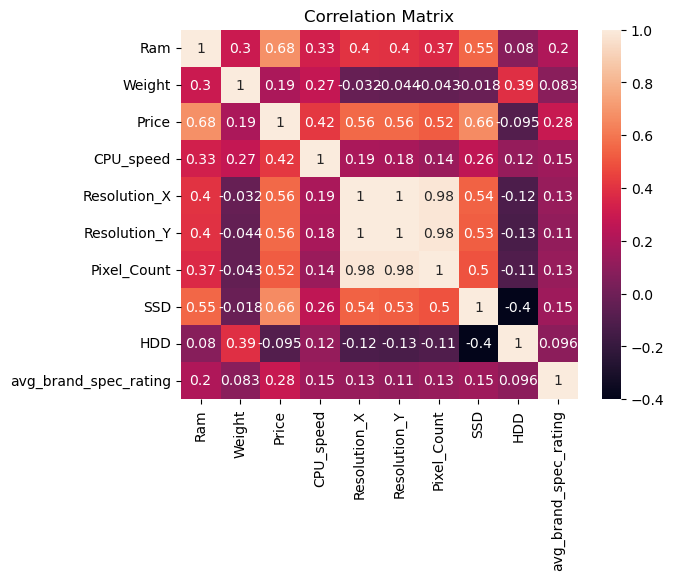

In [17]:
# Correlation (numeric)
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

- RAM and SSD show the the strongest positive correlation with price (0.68 and 0.66 respectively); this indicates they are key drivers of laptop price
- screen resolution related features (Resolution_X, Resolution_Y, Pixel_Count) also have moderate positive correlations with price (0.56, 0.56, and 0.52 respectively)
- CPU speed has moderate positive correlation with price (0.42), suggesting that faster processors contribute to higher-priced laptops
- Weight shows a weak positive correlation with price (0.19), suggesting it is not a strong predictor
- HDD has weak negative correlation with price (-0.095), suggesting that laptops relying more on HDD storage tend to be cheaper
- Resolution_X, Resolution_Y, and Pixel_Count are extremely highly correlated with each other (0.98-1), indicating multicollinearity; one or more of these features may be redundant in modeling
    * presence of multicollinearity among these suggests that feature selection or dimensionality reduction may be beneficial before training the model
- SSD is moderately correlated with resolution and RAM (around 0.5), suggesting that higher-end laptops tend to have multiple premium features together

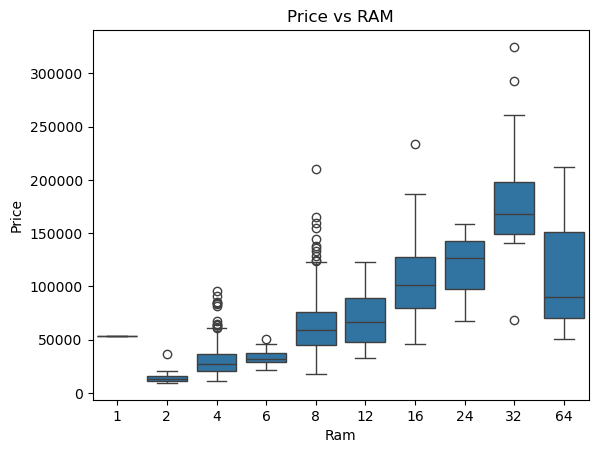

In [18]:
# Price vs RAM
plt.figure()
sns.boxplot(x=df["Ram"], y=df["Price"])
plt.title("Price vs RAM")
plt.show()

- positive relationship between RAM and price; laptops with higher RAM tend to have higher prices
- median price increases steadily as RAM increases, suggesting RAM is a strong predictor of laptop price
- lower RAM (2-8GB) shows lower price ranges with relatively small variation, while higher RAM (16-32GB) shows higher prices and higher variability
- 32GB RAM shows some of the highest prices; suggests it is associated with premium or high-performance laptops
- 64GB category shows high variability and some lower-priced points; may indicate fewer samples or inconsistent pricing in this 'category'
(higher RAM tends to have significantly higher price ranges, suggesting RAM is a strong predictor of price)
- many outliers are present (particularly in mid-range RAM, like 8GB); suggests that other factors such as GPU, brand, or storage could also be influencing price

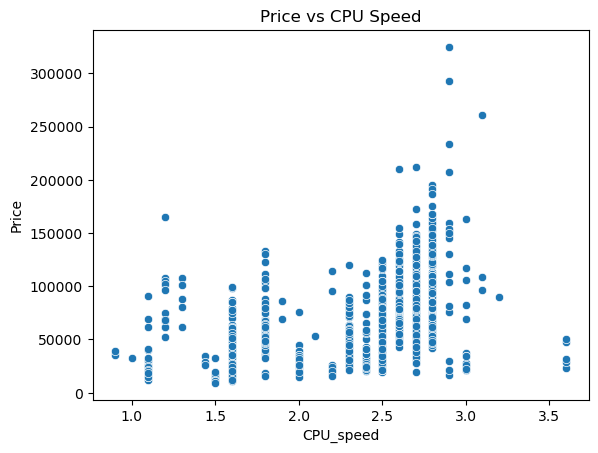

In [19]:
# Price vs CPU speed
plt.figure()
sns.scatterplot(x=df["CPU_speed"], y=df["Price"])
plt.title("Price vs CPU Speed")
plt.show()

- moderate positive relationship between CPU speed and price, with higher GHz values generally corresponding to higher prices
    * relationship is not perfectly linear; there is significant variation in price for similar CPU speeds
- suggests that CPU speed alone does not determine price, and other factors also play a major role (like RAM, GPU, and storage)
- higher CPU speeds show greater dispersion in price, suggesting a mix of mid-range and premium laptops
- few high price outliers are visible at higher CPU speeds, showing (maybe) high-end devices with additional premium features

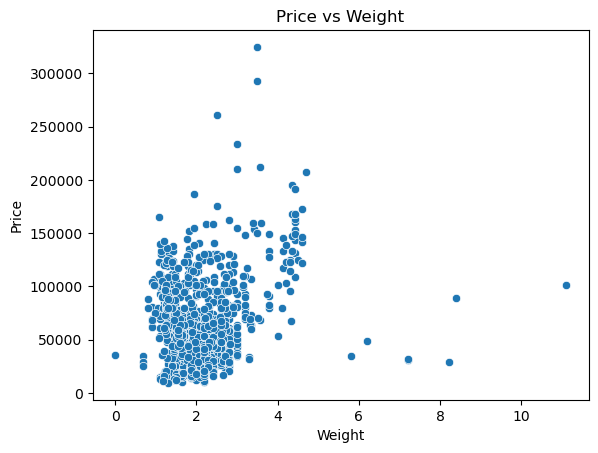

In [20]:
# Price vs Weight
plt.figure()
sns.scatterplot(x=df["Weight"], y=df["Price"])
plt.title("Price vs Weight")
plt.show()

- weak positive relationship between weight and price, suggestng heavier laptops are slightly more expensive on average; the trend is not strong
- most laptops are in the 1.5-3 kg range, with a wide spread of prices within this weight range; suggests weight alone is not a strong predictor of price
- large vertical spread at common weights shows that other features have a greater influence on price (liek RAM, CPU, and GPU)
- many outliers are present, including very heavy laptops with relatively low prices and some mid-weight laptops with very high prices
(weight appears to have limited predictive power compared to other variables like RAM or SSD)

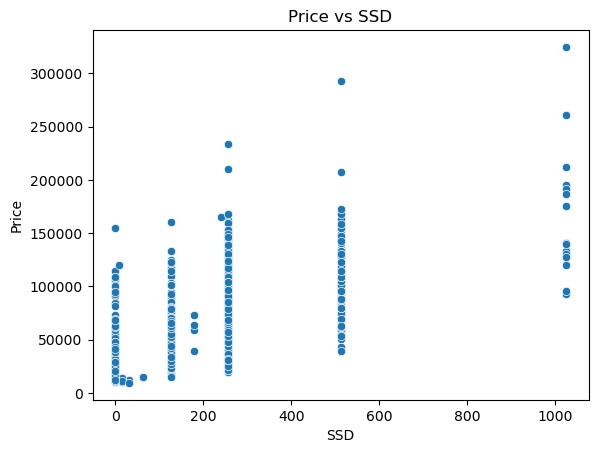

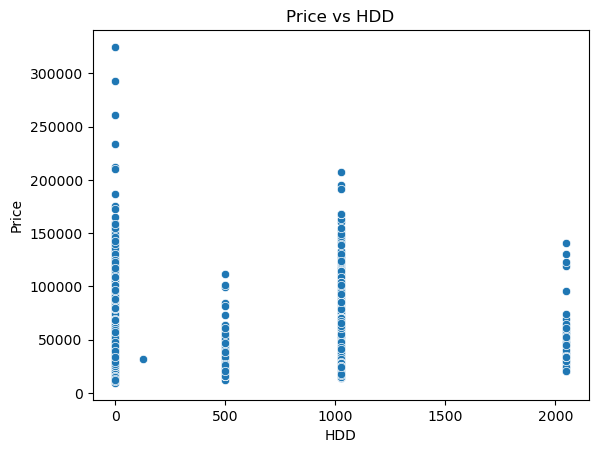

In [21]:
# Price vs Storage
plt.figure()
sns.scatterplot(x=df["SSD"], y=df["Price"])
plt.title("Price vs SSD")
plt.show()

plt.figure()
sns.scatterplot(x=df["HDD"], y=df["Price"])
plt.title("Price vs HDD")
plt.show()

FYI: SSD is solid state drives (use flash memory with no moving parts, faster and more durable) and HDD is hard disk drives (use spinning disks, making them slower but cheaper for high-capacity storage). HDD is older the SSD

SSD
- positive relationship between SSD capacity and price; higher SSD sizes corresponding to more expensive laptops (mostly)
- larger SSD (512 and 1024 GB) tends to have significantly higher price ranges, suggesting SSD is a strong predictor of price
- spread of prices increases with SSD size; could mean higher capacity SSD laptops vary in overall specifications and performance levels (idk though)
- lower SSD capacities, there is noticeable variation in price, indicating that other factors also influence pricing (like RAM, CPU, GPU)

HDD
- little to no positive relationship between HDD capacity and price; in some cases, a slight negative relationship
- larger HDD capacities (1-2TB) are often not the most expensive, suggesting HDD is associated with more budget or older devices
- high-priced laptops are mostly found in low or zero HDD 'categories'; suggests a preference for SSD storage in premium devices
- high-priced laptops are more commonly found in low or zero HDD categories, indicating a preference for SSD storage in premium devices

(SSD capacity appears to be a much stronger indicator of laptop price than HDD capacity, showing modern trends toward faster solid-state storage in higher-end devices)

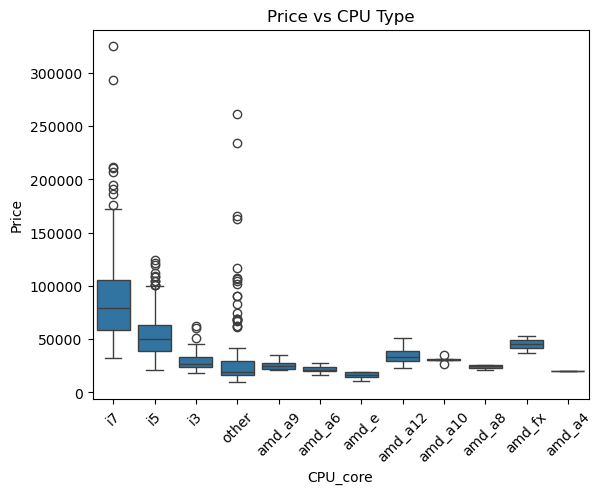

In [22]:
# Price vs CPU type
plt.figure()
cpu_order = df["CPU_core"].value_counts().index
sns.boxplot(x=df["CPU_core"], y=df["Price"], order=cpu_order)
plt.title("Price vs CPU Type")
plt.xticks(rotation=45)
plt.show()

- higher speed processors correspond to higher laptop prices:
    * i7 processors have the highest median price and the widest price range; indicates they are commonly used in high-performance and premium devices
    * i5 laptops fall in the mid-price range; shows moderate performance and cost compared to other CPU types
    * i3 laptops are generally lower-priced; shows their use in budget or entry-level devices
- going from i3 to i5 to i7, there is a string increasing trend, showing that CPU is a strong predictor of laptop price
- “other” shows a wide spread with several high-price outliers; suggests it includes a mix of specialized or less common processors
- AMD processors generally fall into the lower to mid-price range compared to Intel; lower median prices, suggesting they are commonly used in budget or entry-level laptops
    * "higher level" AMD processors (amd_fx and amd_a12) show slightly higher prices but still below Intel
- AMD processors show less variability in thier price compared to Intel; arrower interquartile ranges and fewer extreme outliers suggests consistent pricing
- Some AMD processors (and_a4, amd_a12, and amd_e) have very limited data and should be interpreted cautiously
(AMD processors show a weaker upward price trend compared to Intel)

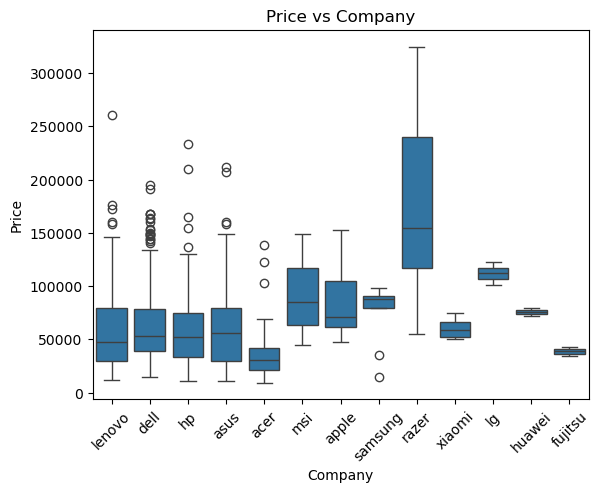

In [23]:
# Price vs Company
plt.figure()
company_order = df["Company"].value_counts().index
sns.boxplot(x=df["Company"], y=df["Price"], order=company_order)
plt.title("Price vs Company")
plt.xticks(rotation=45)
plt.show()

- significant variation in laptop prices across different companies; suggests that brand plays an important role in pricing
- companies like Razer, LG, and MSI have higher median prices, suggesting a focus on premium or high-performance devices
- apple also shows relatively high prices, consistent with its positioning as a premium brand
- acer, asus, and lenovo exhibit a wide range of prices, indicating they offer both budget and high-end laptops
- some companies have consistently lower price ranges, reflecting a focus on budget-friendly devices
- presence of numerous outliers across brands suggests that even typically mid-range companies offer occasional high-end models
(company/brand is an important categorical feature; it captures differences in pricing strategies and market positioning)
- Fujitsu, Huawei, LG, and Xiaomi have very small sample sizes (2-4), so their statistics may not be reliable/representative (also mentioned in the summary table below)

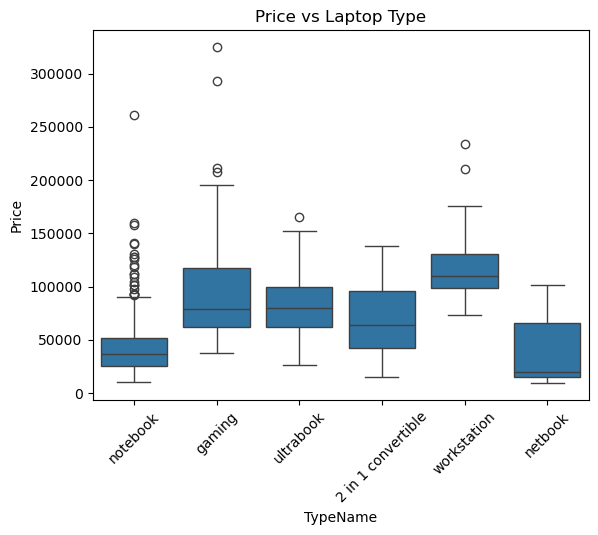

In [24]:
# Price vs Laptop type
plt.figure()
type_order = df["TypeName"].value_counts().index
sns.boxplot(x=df["TypeName"], y=df["Price"], order=type_order)
plt.title("Price vs Laptop Type")
plt.xticks(rotation=45)
plt.show()

- variation in price across different laptop types, suggesting that laptop category is an important factor in pricing
- workstations and gaming laptops have the highest median prices, reflecting their high-performance components and specialized use cases
- ultrabooks also show relatively high prices, likely due to their premium design and quality
- 2 in 1 convertibles fall in the mid-range, balancing portability and functionality
- gaming laptops exhibit a wide spread of prices and several high-value outliers, suggesting a mix of mid-range and premium options
(laptop type is a strong categorical predictor of price, capturing differences in performance, design, and intended use)

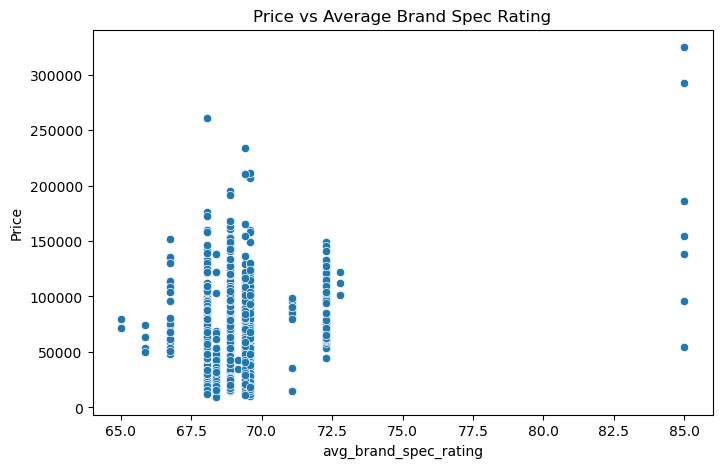

In [25]:
# Price vs average brand spec rating
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["avg_brand_spec_rating"], y=df["Price"])
plt.title("Price vs Average Brand Spec Rating")
plt.show()

- general positive relationship between spec rating and price; brands with higher average spec ratings have more high-priced devices
    * the highest prices in the dataset are mostly associated with higher spec rating brands; suggests this feature has predictive value (ooouuuuuuu)
- relationship is not strictly linear; vertical spread at most spec rating levels, emans laptops with similar brand ratings still have very different prices, suggesting other features also strongly influence price (like RAM, CPU, GPU)
- most data points are between around 67 and 70, suggesting most brands fall into a similar spec rating range; prices vary in this range, again, brand alone is not a good predictor price
- there are less high spec rating brands but they skew towards premium pricing

In [26]:
# Summary table for the brand-level feature
brand_summary = (
    df.groupby("Company")[["avg_brand_spec_rating", "Price"]].describe()
)

brand_summary

avg_brand_spec_rating                                                 \
                        count       mean           std        min        25%   
Company                                                                        
acer                    101.0  68.367347  1.142539e-13  68.367347  68.367347   
apple                    21.0  66.750000  0.000000e+00  66.750000  66.750000   
asus                    149.0  69.584071  1.853642e-13  69.584071  69.584071   
dell                    281.0  68.879310  4.270863e-14  68.879310  68.879310   
fujitsu                   2.0  69.166667  0.000000e+00  69.166667  69.166667   
hp                      260.0  69.425373  1.281444e-13  69.425373  69.425373   
huawei                    2.0  65.000000  0.000000e+00  65.000000  65.000000   
lenovo                  282.0  68.066116  1.423612e-14  68.066116  68.066116   
lg                        3.0  72.777778  0.000000e+00  72.777778  72.777778   
msi                      53.0  72.271186  7.173423e-14  72.271186  72.271186   
razer                     7.0  85.000000  0.000000e+00  85.000000  85.000000   
samsung                   9.0  71.095238  1.507289e-14  71.095238  71.095238   
xiaomi                    4.0  65.857143  0.000000e+00  65.857143  65.857143   

                                          Price                               \
               50%        75%        max  count           mean           std   
Company                                                                        
acer     68.367347  68.367347  68.367347  101.0   33750.986186  20050.879958   
apple    66.750000  66.750000  66.750000   21.0   83340.499886  29923.305164   
asus     69.584071  69.584071  69.584071  149.0   60310.535581  37696.943639   
dell     68.879310  68.879310  68.879310  281.0   63963.889520  36163.000811   
fujitsu  69.166667  69.166667  69.166667    2.0   38574.720000   5651.197395   
hp       69.425373  69.425373  69.425373  260.0   57910.511520  33163.628037   
huawei   65.000000  65.000000  65.000000    2.0   75870.720000   5651.197395   
lenovo   68.066116  68.066116  68.066116  282.0   58486.170179  37241.529209   
lg       72.777778  72.777778  72.777778    3.0  111834.720000  10656.000000   
msi      72.271186  72.271186  72.271186   53.0   91814.548891  28439.427377   
razer    85.000000  85.000000  85.000000    7.0  178282.491429  99100.186173   
samsung  71.095238  71.095238  71.095238    9.0   75308.320000  29650.823967   
xiaomi   65.857143  65.857143  65.857143    4.0   60390.882000  11198.819633   

                                                                        
                 min         25%          50%          75%         max  
Company                                                                 
acer       9270.7200   20725.920   30476.1600   41505.1200  138474.720  
apple     47895.5232   61964.640   71378.6832  104370.1920  152274.240  
asus      10602.7200   30049.920   55938.6720   79866.7200  211788.000  
dell      14646.6720   39373.920   53226.7200   78694.5600  194972.832  
fujitsu   34578.7200   36576.720   38574.7200   40572.7200   42570.720  
hp        11135.5200   33513.120   52161.1200   74538.7200  233845.920  
huawei    71874.7200   73872.720   75870.7200   77868.7200   79866.720  
lenovo    12201.1200   29250.720   47898.7200   79733.3868  261018.720  
lg       101178.7200  106506.720  111834.7200  117162.7200  122490.720  
msi       44701.9200   63882.720   85194.7200  117162.7200  149130.720  
razer     54825.1200  117162.720  154458.7200  239706.7200  324954.720  
samsung   14332.3200   79866.720   87858.7200   90522.7200   98514.720  
xiaomi    49816.8000   52410.204   58578.6960   66559.3740   74589.336

- higher spec ratings generally align with higher prices
    * brands like Razer and LG have higher average spec ratings and also show higher mean prices; this suggests a positive relationship between brand quality and price
- premium brands show higher price variability; Razer, MSI, and Apple have large standard deviations in price, suggesting many differert models from mid-range to premium
- mainstream brands have lower average prices but still wide distributions; Acer, HP, Lenovo, and Dell have lower average prices but high variability, suggesting laptops across multiple market segments
- Fujitsu, Huawei, LG, and Xiaomi have very small sample sizes (2-4), so their statistics may not be reliable/representative (also mentioned in the Price vs Company plot above)
(noticeable differences in price distributions, suggesting that other features influence price (like RAM, CPU, and GPU))